In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from ipywidgets import interact
import ipywidgets as widgets
import matplotlib
import xarray as xr
import netCDF4
import numpy as np
from scipy.stats import mannwhitneyu

# Change working directory
import os
os.chdir(os.getcwd() + "/../")
print(os.getcwd())

import config
from visualisation.plotting import coupled_label_plot, plot_each_depth_level, plot_ts, plot_geo, plot_embedding, compare_stats

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation


In [2]:
# Load data (as df and nc)
df = pd.read_csv(f"{config.output_dir}cluster_set.csv")
nc = netCDF4.Dataset(f"{config.output_dir}cluster_set.nc")

In [3]:
# General cluster info
num_clusters = len(df.label.unique())
num_noise = len(df[df.label == 8])
noise_frac = round(num_noise/len(df)*100, 2)

print(f"The final cluster set has {num_clusters} clusters (incl. DBSCAN noise cluster) and {noise_frac}% noise ({num_noise} grid cells).")


The final cluster set has 321 clusters (incl. DBSCAN noise cluster) and 3.92% noise (1920 grid cells).


In [4]:
# Exclude noise label
df = df[df.label != 8]  

## Label plots

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:130: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


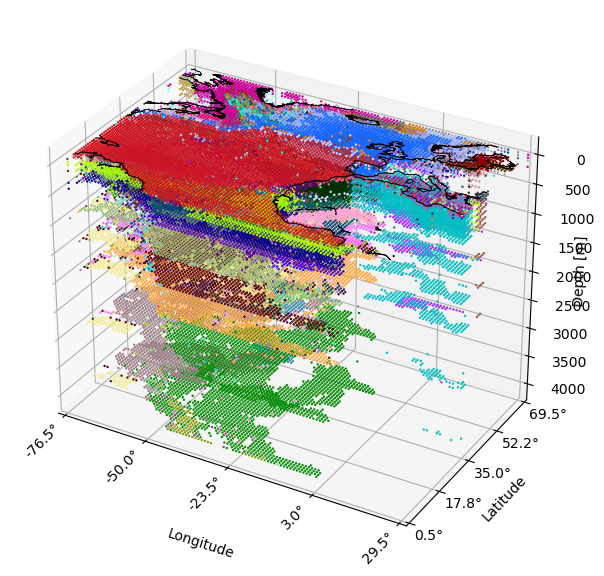

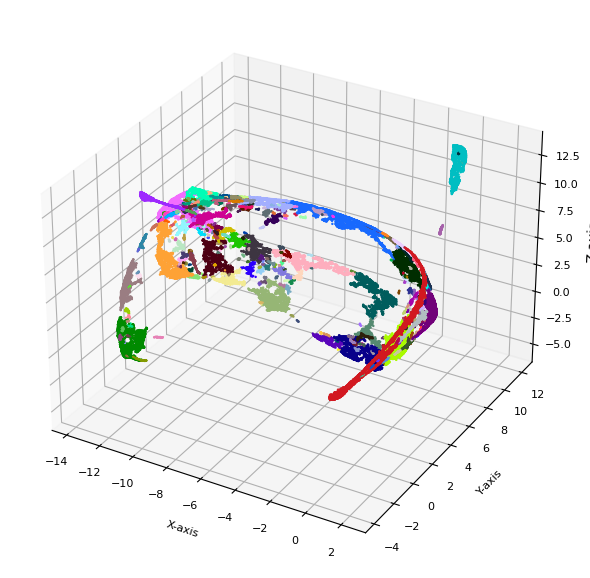

In [5]:
coupled_label_plot(df, color_label="color", save_dir=config.output_dir_plots_high_res, suffix="_final", save_as=None, figsize=(6, 6),
                       fontsize=8, ticklabelsize=8,
                       adjust_left=0, adjust_right=0.92, adjust_top=1.1, adjust_bottom=-0.05, pointsize=0.5, dpi=1300,
                       xlabelpad=20, ylabelpad=0, zlabelpad=0)

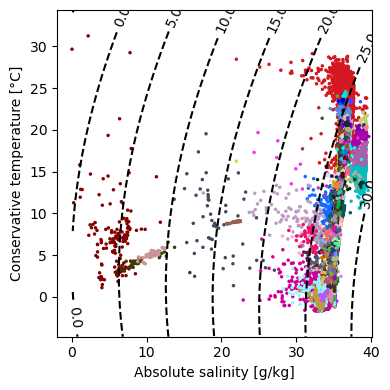

In [7]:
plot_ts(df, figsize=(4, 4), dpi=1000, ncols=None, xlim=None, save_as=f"{config.output_dir_plots_high_res}final_ts.png", fontsize=None)

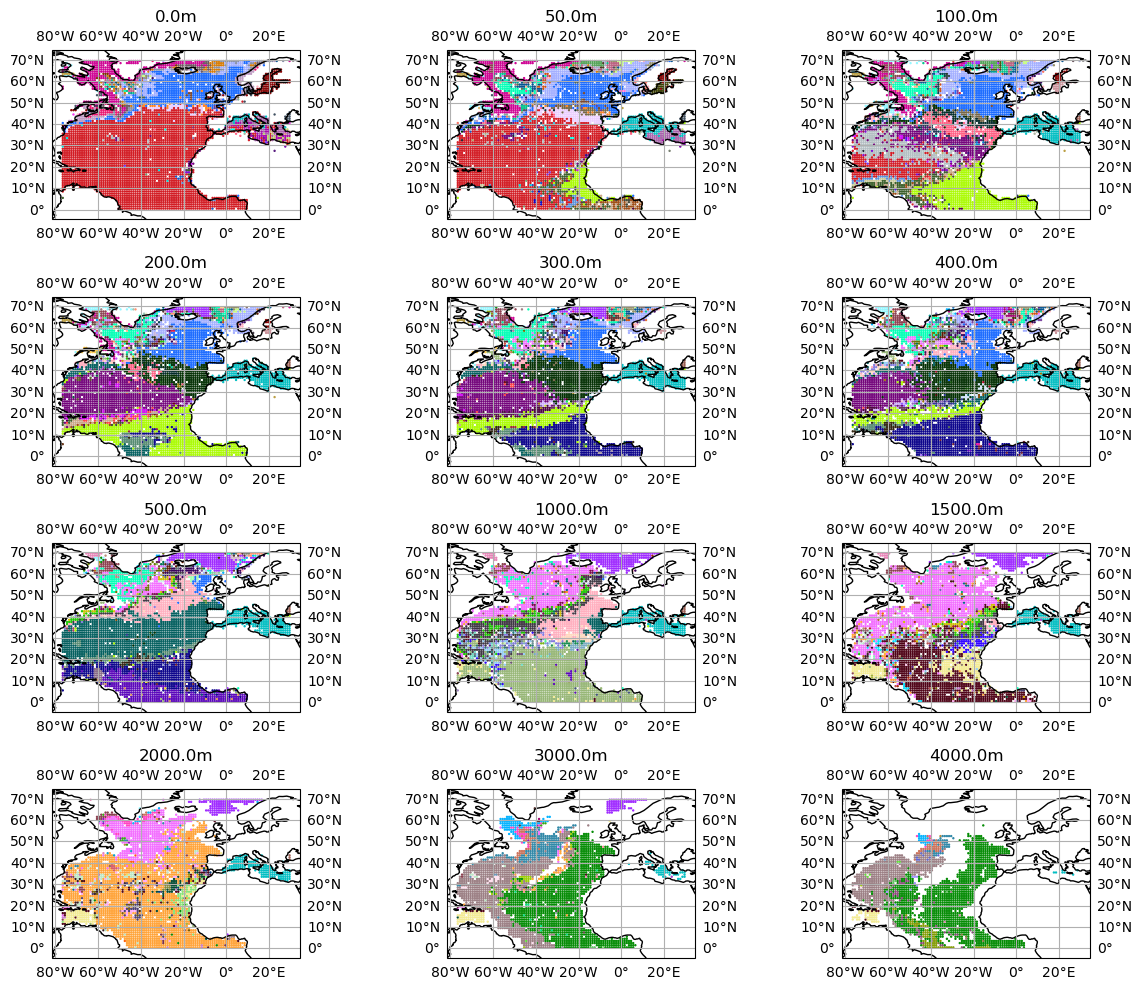

In [8]:
plot_each_depth_level(df, color_label="color", save_as=f"{config.output_dir_plots}final_depth_levels.png")

In [9]:
# Interactive depth-layer plot

# Defining our area of interest
lat_min = 0
lat_max = 70

lon_min = -77
lon_max = 30

# Plot settings
factor = 12
mymap = Basemap(llcrnrlon=lon_min, llcrnrlat=lat_min, urcrnrlon=lon_max, urcrnrlat=lat_max)
plt.rcParams["figure.figsize"] = ((lon_max - lon_min)/factor, (lat_max - lat_min)/factor)

# Plot
def plot_over_depth(depth_level):
    hex_colors = nc["color"][depth_level, :, :]  #.data
    rgb = np.array([[matplotlib.colors.to_rgb(color) if type(color) == str and color is not None and color != "" else np.array([1, 1, 1]) for color in row] for row in hex_colors])
    mymap.imshow(rgb)  # , cmap=cm, vmin=vmin, vmax=vmax)
    mymap.drawcoastlines(linewidth=0.5)
    mymap.fillcontinents()
    mymap.drawparallels(np.arange(int(lat_min),int(lat_max), 10),labels=[1,0,0,0])
    mymap.drawmeridians(np.arange(int(lon_min),int(lon_max), 10),labels=[0,0,0,1])
    plt.tight_layout()
    # plt.savefig(output_dir + f"my_clustering_{depth_level}.svg")
    # plt.savefig(output_dir + f"my_clustering_{depth_level}.png")
    plt.savefig(f"{config.output_dir_plots_high_res}/my_clustering_{depth_level}.png", dpi=1000)

depth_levels = np.array((range(nc["LEV_M"].shape[0])))
interact(plot_over_depth, depth_level=widgets.IntSlider(value=depth_levels.min(), min=depth_levels.min(), max=depth_levels.max(), step=1))

plt.show()

interactive(children=(IntSlider(value=0, description='depth_level', max=11), Output()), _dom_classes=('widget-…

### Case study: Mediterranean Sea

In [5]:
# Count clusters in the geographic area
lon_min = -6
lon_max = 30
lat_min = 30
lat_max = 48

medi = df[(df.LONGITUDE <= lon_max) &  (df.LONGITUDE >= lon_min) & (df.LATITUDE <= lat_max) & (df.LATITUDE >= lat_min)]
medi = medi.drop(medi[(medi.LONGITUDE < 0) & (medi.LATITUDE > 42)].index)  # cut out Biskay
medi = medi.drop(medi[(medi.LONGITUDE > 27) & (medi.LATITUDE > 40)].index) # cut out Red Sea

print(f"Number of clusters in the geographic area of the Mediterranean Sea: {len(medi.label.unique())}\nNumber of grid cells: {len(medi)}")

Number of clusters in the geographic area of the Mediterranean Sea: 27
Number of grid cells: 2509


In [6]:
# Number/proportion of grid cells per cluster
medi["label"].value_counts()#/len(medi)*100

label
6      2092
35      173
62       74
0        73
138      22
150      11
146       7
225       7
228       6
129       6
28        6
301       5
358       5
5         3
178       3
4         3
20        2
140       2
69        1
89        1
110       1
318       1
75        1
79        1
10        1
149       1
64        1
Name: count, dtype: int64

In [7]:
# Select most important labels
medi_labels_selection = [6, 32, 35, 138] + [0, 10, 19, 28] 
medi_selection = df[df.label.isin(medi_labels_selection)]

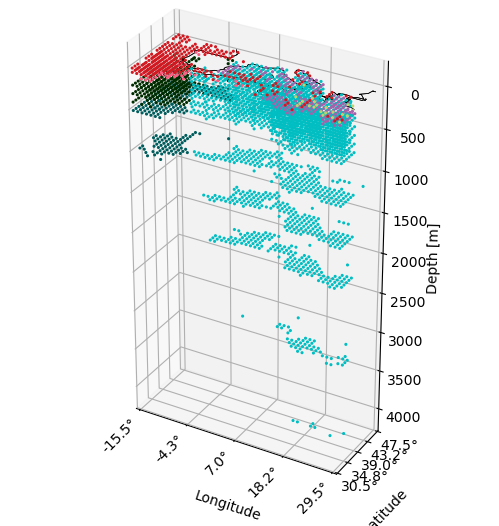

In [14]:
# Geographic plot
medi_geo =  df[(df.LONGITUDE <= lon_max) &  (df.LONGITUDE >= lon_min - 10) & (df.LATITUDE <= lat_max) & (df.LATITUDE >= lat_min) & (df.label.isin(medi_labels_selection))]

filename = config.output_dir_plots_high_res + "labels_in_geospace" + "_medi" + ".png" 

plot_geo(medi_geo, color_label="color", save_as=filename, figsize=(6, 6), 
         pointsize=1.5, dpi=1000, 
         adjust_left=0, adjust_right=0.88, adjust_top=0.95, adjust_bottom=0.15, 
         xlabelpad=10, ylabelpad=5, zlabelpad=15)


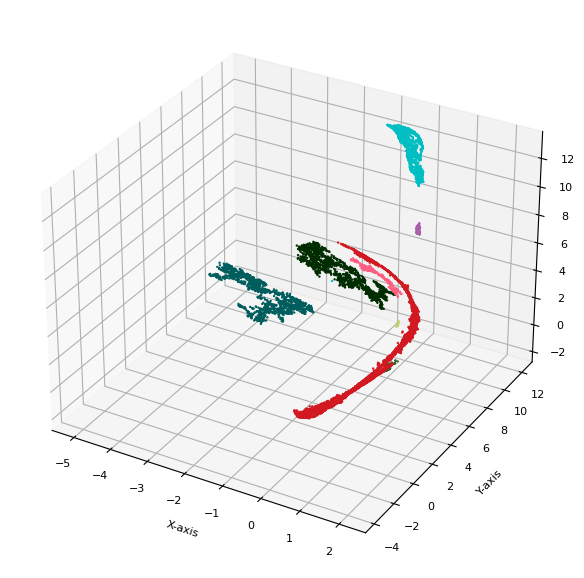

In [24]:
# UMAP plot
filename = config.output_dir_plots_high_res + "labels_in_umapspace" + "_medi" + ".png" 
plot_embedding(medi_selection, color_label="color", save_as=filename, figsize=(6, 6), dpi=1900, alpha=1)


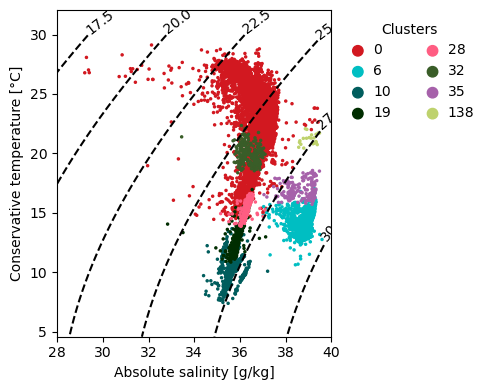

In [17]:
plot_ts(medi_selection, figsize=(5, 4), dpi=1000, ncols=2, xlim=[28, 40], save_as=f"{config.output_dir_plots_high_res}medi_ts.png", legend_loc="upper left", anchor=(1, 1))

### Case study: Deep Atlantic waters

In [52]:
# Define geographic extent
deep = df[df.LEV_M >= 3000]
deep = deep.drop(index=deep.index.intersection(medi.index))  # Cut out Mediterranean

print(f"Number of clusters in the geographic area of the deep waters: {len(deep.label.unique())}\nNumber of grid cells: {len(deep)}")

Number of clusters in the geographic area of the deep waters: 43
Number of grid cells: 4946


In [56]:
# Number/proportion of grid cells per cluster
deep["label"].value_counts()#/len(deep)*100

label
2      2555
11     1339
31      239
42      104
22      104
52       86
51       85
14       70
100      47
7        45
104      43
59       29
122      29
143      20
15       16
3        16
169      15
181      12
199      10
235       8
249       7
202       7
85        7
49        6
274       6
273       6
243       6
164       4
68        4
209       3
63        3
281       2
24        2
268       2
123       1
82        1
163       1
168       1
60        1
87        1
96        1
231       1
107       1
Name: count, dtype: int64

In [70]:
# Mean uncertainties per cluster
deep[["label", "uncertainty"]].groupby("label").mean().sort_values("uncertainty")

,uncertainty
label,
60,0.000000
14,0.000000
209,0.000000
85,0.000000
51,0.517647
42,0.605769
31,0.690377
87,1.000000
24,1.000000


In [57]:
# Select most important labels
deep_labels_selection = [2, 11, 31, 42, 51, 52]
deep_selection = df[df.label.isin(deep_labels_selection)]

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:130: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


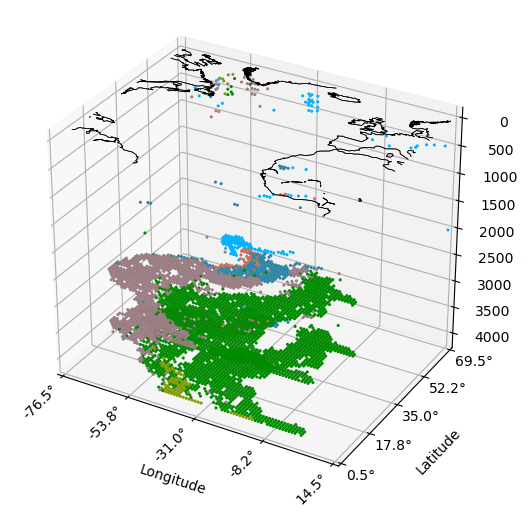

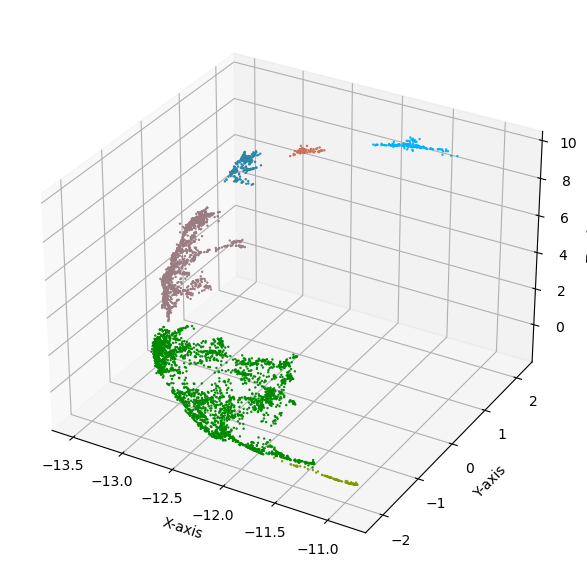

In [58]:
coupled_label_plot(deep_selection, color_label="color", 
                         save_dir=config.output_dir_plots_high_res, 
                         suffix="_deep", 
                         figsize=(6, 6), pointsize=1.5, fontsize=None, 
                         ticklabelsize=None, dpi=1000, 
                         adjust_left=0, adjust_right=0.88, 
                         adjust_top=0.95, adjust_bottom=0.15, 
                         xlabelpad=10, ylabelpad=5, zlabelpad=15)

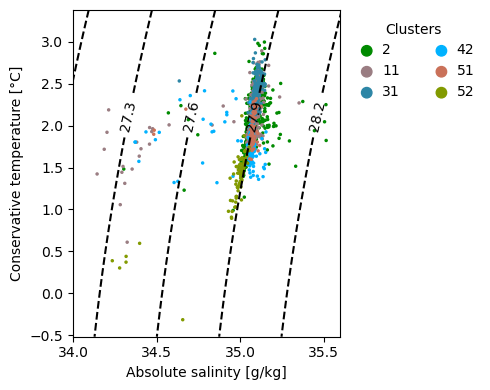

In [61]:
plot_ts(deep_selection, figsize=(5, 4), dpi=1000, ncols=2, xlim=[34, 35.6], save_as=f"{config.output_dir_plots_high_res}deep_ts.png", legend_loc="upper left", anchor=(1, 1))

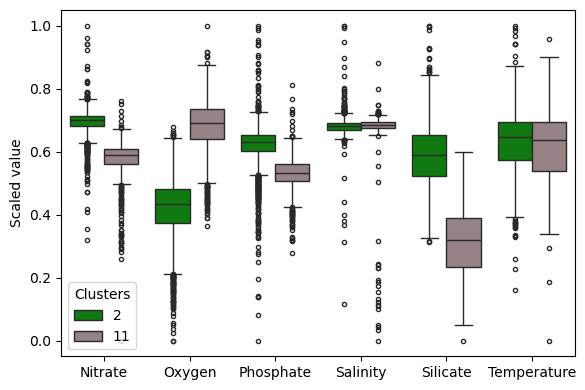

In [64]:
compare_stats(df=df, labels=[2, 11], save_as=f"{config.output_dir_plots_high_res}comparing_2_and_11.png", figsize=(6, 4), dpi=1000)

,P_TEMPERATURE,P_SALINITY,P_OXYGEN,P_NITRATE,P_SILICATE,P_PHOSPHATE,LATITUDE,LONGITUDE,LEV_M,imputed,water,e0,e1,e2,volume,label,uncertainty,color
23735,1.478932,34.140333,259.000000,11.800000,45.731361,1.210000,68.5,-52.5,300.0,16.67,0,-12.936293,-1.182733,1.209698,4.541715e+11,2,10.0,#008a00
23795,2.151652,34.405500,257.333333,14.140485,41.143327,1.320000,69.5,-58.5,300.0,33.33,1,-12.981321,-1.161499,1.188035,4.339800e+11,2,10.0,#008a00
27921,2.071297,34.523703,246.860714,12.752276,54.580000,1.015800,65.5,-58.5,400.0,16.67,1,-12.092375,-0.325566,-0.412458,5.138914e+11,2,1.0,#008a00
28023,2.238402,34.479714,254.174000,16.498500,47.564500,1.220475,67.5,-58.5,400.0,0.00,1,-12.506602,-1.655857,0.106709,4.742246e+11,2,31.0,#008a00
32212,2.864945,34.681381,252.500000,15.823365,41.156157,1.298000,65.5,-58.5,500.0,33.33,0,-13.057549,-0.731970,0.635064,2.569457e+12,2,6.0,#008a00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49024,2.132455,34.901842,241.630341,22.195053,44.132789,1.467632,52.5,-18.5,4000.0,0.00,1,-12.737381,-1.221051,-1.197753,7.543824e+12,2,1.0,#008a00
49025,2.145200,34.906663,240.803317,22.209765,44.651500,1.494253,52.5,-17.5,4000.0,0.00,0,-12.707430,-1.159123,-1.274408,7.543824e+12,2,1.0,#008a00
49026,2.117379,34.902333,239.700000,21.953333,42.020000,1.400000,52.5,-16.5,4000.0,0.00,0,-12.656770,-0.847334,-0.831213,7.543824e+12,2,27.0,#008a00
49028,2.212268,34.901000,240.780000,22.480000,45.160000,1.513200,53.5,-22.5,4000.0,0.00,1,-12.696537,-1.187640,-1.294750,7.371095e+12,2,1.0,#008a00


In [75]:
# Perform Mann-Whitney U test (to test for significance of differences between the two labels for every parameter)
for col in config.parameters:
    stat, p = mannwhitneyu(df[df.label == 2][col], df[df.label == 11][col], alternative='two-sided')
    print(f"{col}: U = {stat:.2f}, p = {p:.4f}")

P_TEMPERATURE: U = 1877721.00, p = 0.0004
P_SALINITY: U = 1450858.00, p = 0.0000
P_OXYGEN: U = 75628.50, p = 0.0000
P_NITRATE: U = 3434267.50, p = 0.0000
P_SILICATE: U = 3467499.00, p = 0.0000
P_PHOSPHATE: U = 3198825.50, p = 0.0000


### Case study: Labrador Sea

In [79]:
# Define geographic extent
lon_min = -77
lon_max = -40
lat_min = 45
lat_max = 70

lab = df[(df.LONGITUDE <= lon_max) &  (df.LONGITUDE >= lon_min) & (df.LATITUDE <= lat_max) & (df.LATITUDE >= lat_min)]

print(f"Number of clusters in the geographic area of the Labrador Sea: {len(lab.label.unique())}\nNumber of grid cells: {len(lab)}")

Number of clusters in the geographic area of the Labrador Sea: 124
Number of grid cells: 4170


In [94]:
# Check cluster size
lab_selection.label.value_counts()[:10]

label
3     2599
17     921
18     912
24     430
30     270
42     152
Name: count, dtype: int64

In [93]:
# Analyse cluster depth
for l in lab_selection.label.unique():
    filtered = df[df.label == l]
    print(l, filtered.LEV_M.unique())

24 [   0.   50.  100.  200.  300.  400.  500. 1000. 1500. 2000. 3000.]
17 [  0.  50. 100. 200. 300. 400.]
30 [   0.   50.  100.  200.  300.  400.  500. 1000. 2000.]
18 [   0.   50.  100.  200.  300.  400.  500. 1000. 1500.]
3 [ 100.  200.  300.  400.  500. 1000. 1500. 2000. 3000.]
42 [ 200.  300.  400.  500. 1500. 2000. 3000. 4000.]


In [82]:
# Select most important labels
lab_labels_selection = [3, 17, 18, 24, 30, 42]
lab_selection = df[df.label.isin(lab_labels_selection)]

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:130: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


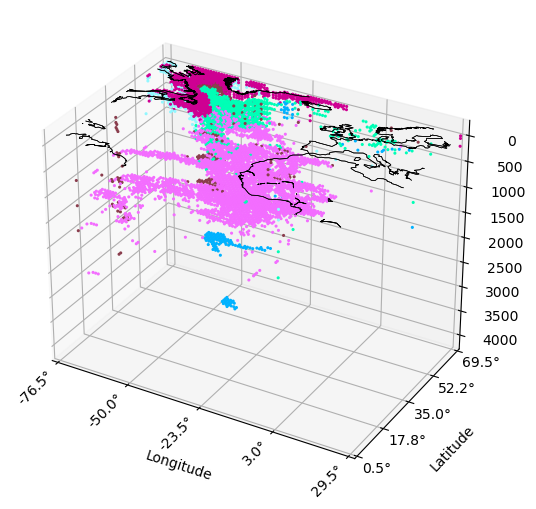

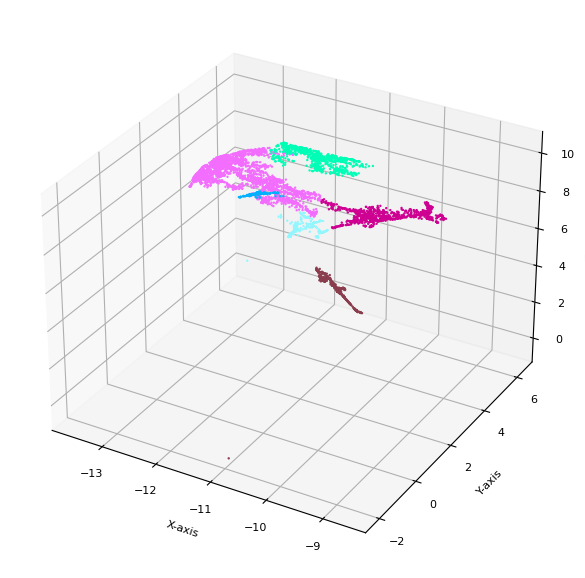

In [83]:
coupled_label_plot(lab_selection, color_label="color", 
                   save_dir=config.output_dir_plots_high_res, suffix="_lab", 
                   figsize=(6, 6), pointsize=1.5, dpi=1000, 
                   adjust_left=0, adjust_right=0.88, adjust_top=0.95, adjust_bottom=0.15,
                   xlabelpad=10, ylabelpad=5, zlabelpad=15)

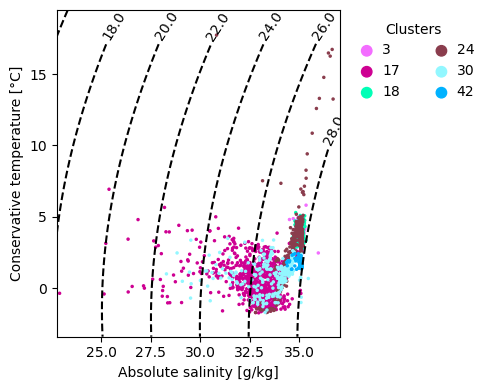

In [84]:
plot_ts(lab_selection, figsize=(5, 4), dpi=1000, ncols=2, xlim=None, save_as=f"{config.output_dir_plots_high_res}lab_ts.png", legend_loc="upper left", anchor=(1, 1))

## Uncertainty plots

In [25]:
def coupled_label_plot_uncertainties(df, save_dir=None, suffix="", save_as=None, figsize=(6, 6), fontsize=None, ticklabelsize=None, 
                       adjust_left=0, adjust_right=0.92, adjust_top=1.1, adjust_bottom=-0.05, pointsize=0.5, dpi=1000,
                      xlabelpad=20, ylabelpad=0, zlabelpad=0,
                                    cpad=0.05):
    """ Plots cluster labels in geographical and embedded space. """
    if save_as is None:
        save_as = ["labels_in_geospace", "labels_in_umapspace"]
    temp = df.copy()

    # define basemap
    mymap = Basemap(llcrnrlon=temp["LONGITUDE"].min(), llcrnrlat=temp["LATITUDE"].min(), 
                    urcrnrlon=temp["LONGITUDE"].max(), urcrnrlat=temp["LATITUDE"].max(), fix_aspect=False)

    # geographical plot
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(projection='3d')
    sc_3d = ax.scatter(temp["LONGITUDE"], temp["LATITUDE"], temp["LEV_M"], c=temp["uncertainty"], s=pointsize, alpha=1, zorder=4, vmin=0, vmax=100) 
    ax.add_collection3d(mymap.drawcoastlines(linewidth=0.5))
    ax.set_box_aspect((np.ptp(temp["LONGITUDE"]), np.ptp(temp["LATITUDE"]), np.ptp(temp["LEV_M"])/50))

    # Add axis labels
    ax.set_xlabel('Longitude', labelpad=xlabelpad)
    ax.set_ylabel('Latitude', labelpad=ylabelpad)
    ax.set_zlabel('Depth [m]', labelpad=zlabelpad)

    # Invert the Z-axis for depth representation
    plt.gca().invert_zaxis()

    # Define coarse ticks for longitude and latitude
    lon_ticks = np.linspace(temp["LONGITUDE"].min(), temp["LONGITUDE"].max(), num=5)  # Adjust num for desired spacing
    lat_ticks = np.linspace(temp["LATITUDE"].min(), temp["LATITUDE"].max(), num=5)

    # Set ticks and labels
    ax.set_xticks(lon_ticks)  # Longitude ticks
    ax.set_xticklabels([f"{tick:.1f}°" for tick in lon_ticks], rotation=45, ha="right")  # Format as degrees

    ax.set_yticks(lat_ticks)  # Latitude ticks
    ax.set_yticklabels([f"{tick:.1f}°" for tick in lat_ticks], rotation=0, ha="left")  # Format as degrees

    # Increase padding between ticks and their labels
    ax.tick_params(axis='x', pad=-5)  # Horizontal ticks
    ax.tick_params(axis='y', pad=-5)  # Vertical ticks
    ax.tick_params(axis='z', pad=10)  # Depth ticks

    # Colorbar
    plt.colorbar(sc_3d, location="bottom", label="Uncertainty [%]", fraction=0.05, pad=cpad)

    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(left=adjust_left, right=adjust_right, top=adjust_top, bottom=adjust_bottom)

    # Save figure
    if save_dir is not None:
        plt.savefig(save_dir + save_as[0] + suffix + ".png", dpi=dpi)
    plt.show()

    # UMAP plot
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(projection='3d')
    sc_umap = ax.scatter(temp["e0"], temp["e1"], temp["e2"], c=temp["uncertainty"], alpha=0.8, s=1, marker=".", zorder=4, vmin=0, vmax=100)   
    
    plt.xlabel("X-axis", fontsize=fontsize)
    plt.ylabel("Y-axis", fontsize=fontsize)
    ax.set_zlabel("Z-axis", fontsize=fontsize)
    ax.tick_params(axis='x', labelsize=ticklabelsize)#, pad=tick_padding)
    ax.tick_params(axis='y', labelsize=ticklabelsize)#, pad=tick_padding)
    ax.tick_params(axis='z', labelsize=ticklabelsize)#, pad=tick_padding)

    plt.colorbar(sc_umap, location="bottom", label="Uncertainty [%]", fraction=0.05, pad=0.05)
    plt.tight_layout()
    plt.subplots_adjust(left=-0.05, right=1, top=1, bottom=0.1)
    if save_as:
        filename = save_dir + save_as[1] + suffix + ".png" if save_dir is not None else None
        plt.savefig(filename, dpi=dpi)
    plt.show()

In [31]:
import gsw 

def plot_ts_uncertainty(df, figsize=(4, 4), dpi=None, ncols=5, xlim=None, save_as=None, fontsize=None, ticklabelsize=None):
    """ Plot T-S diagram. """
    temp = df.copy()
    
    # compute necessary parameters
    temp["pressure"] = gsw.p_from_z(-1*temp["LEV_M"], temp["LATITUDE"])
    temp["abs_salinity"] = gsw.SA_from_SP(temp["P_SALINITY"], temp["pressure"], temp["LONGITUDE"], temp["LATITUDE"])
    temp["cons_temperature"] = gsw.CT_from_pt(temp["abs_salinity"], temp["P_TEMPERATURE"])
    temp["rho"] = gsw.rho(temp["abs_salinity"], temp["cons_temperature"], temp["pressure"])

    # limits
    smin = temp["abs_salinity"].min() - (0.01 * temp["abs_salinity"].min())
    smax = temp["abs_salinity"].max() + (0.01 * temp["abs_salinity"].max())
    tmin = temp["cons_temperature"].min() - (0.1 * temp["cons_temperature"].max())
    tmax = temp["cons_temperature"].max() + (0.1 * temp["cons_temperature"].max())

    if xlim:
        smin = xlim[0] - (0.01 * xlim[0])
        smax = xlim[1] + (0.01 * xlim[1])
    
    # number of gridcells in the x and y dimensions
    xdim = int(round((smax - smin) / 0.1 + 1, 0))
    ydim = int(round((tmax - tmin) / 0.1 + 1, 0))
    
    # empty grid
    dens = np.zeros((ydim, xdim))
    
    # temperature and salinity vectors
    si = np.linspace(1, xdim - 1, xdim) * 0.1 + smin
    ti = np.linspace(1, ydim - 1, ydim) * 0.1 + tmin
    
    # fill grid with densities
    for j in range(0, int(ydim)):
        for i in range(0, int(xdim)):
            dens[j, i] = gsw.rho(si[i], ti[j], 0)
    
    # convert to sigma-t
    dens = dens - 1000

    # plot
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111)
    contours = plt.contour(si, ti, dens, linestyles='dashed', colors='k')
    plt.clabel(contours, fontsize=fontsize, inline=1, fmt='%1.1f')  # label every second level
    sc = ax.scatter(x=temp["abs_salinity"], y=temp["cons_temperature"], c=temp["uncertainty"], s=9, alpha=1, marker=".", vmin=0, vmax=100)
    ax.set_xlabel('Absolute salinity [g/kg]', fontsize=fontsize)
    ax.set_ylabel('Conservative temperature [°C]', fontsize=fontsize)
    ax.set_xlim(xlim)

    plt.subplots_adjust(bottom=0.25)
    plt.colorbar(sc, location="bottom", label="Uncertainty [%]")#, fraction=0.05, pad=0.05,)
    #ax.legend(loc='upper left', title='Clusters', bbox_to_anchor=(0.0, -0.15), ncol=5, fontsize=fontsize, markerscale=5, frameon=False)
    #if ncols:
    #    ax.legend(loc='upper center', title='Clusters', bbox_to_anchor=(0.5, -0.2), ncol=ncols, markerscale=5, frameon=False, handletextpad=0.1)

    plt.tight_layout()
    if save_as:
        plt.savefig(save_as, dpi=dpi)
    plt.show()

In [18]:
# NEMI uncertainties
print(f"The mean NEMI uncertainty is {round(df['uncertainty'].mean(), 1)} +- {round(df['uncertainty'].std(), 1)}% \nMin: {df['uncertainty'].min()}%\nMax: {df['uncertainty'].max()}%\nMedian: {df['uncertainty'].median()}%")


The mean NEMI uncertainty is 15.5 +- 20.0% 
Min: 0.0%
Max: 96.0%
Median: 5.0%


C:\Users\yvjennig\AppData\Local\Temp\ipykernel_12464\3821806950.py:49: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


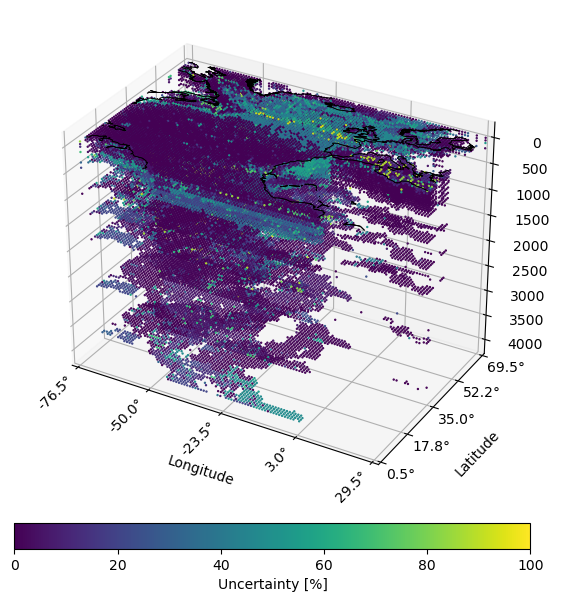

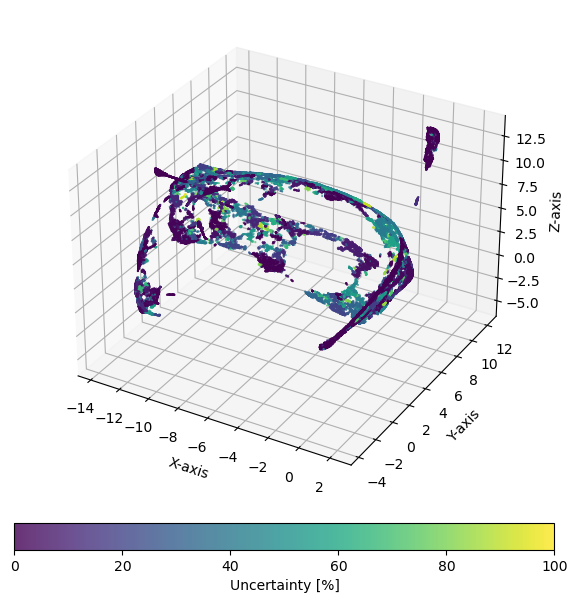

In [26]:
coupled_label_plot_uncertainties(df, save_dir=config.output_dir_plots_high_res, suffix="_uncertainty", figsize=(6, 6), dpi=1000, 
                                 xlabelpad=10, ylabelpad=5, zlabelpad=15, 
                                 adjust_left=0.02, adjust_right=0.88, adjust_top=1, adjust_bottom=0.1)

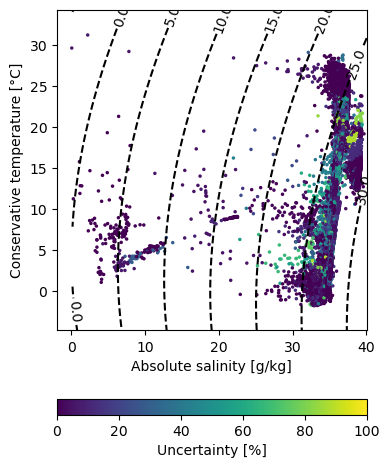

In [35]:
plot_ts_uncertainty(df, figsize=(4, 5), dpi=1000, ncols=None, xlim=None, save_as=f"{config.output_dir_plots_high_res}uncertainty_ts.png")

In [42]:
print("Uncertainty statistics")
print(round(df.uncertainty.mean(), 2), round(df.uncertainty.std(), 2), round(df.uncertainty.median(), 2))

Uncertainty statistics
15.49 19.98 5.0


### Most certain clusters

In [43]:
# Check uncertainty extremes
uncertainty_per_cluster = df[["label", "uncertainty"]].groupby("label").mean().sort_values("uncertainty").reset_index()
uncertainty_eq0 = uncertainty_per_cluster[uncertainty_per_cluster.uncertainty == 0]  # Most certain clusters
uncertainty_meq50 = uncertainty_per_cluster[uncertainty_per_cluster.uncertainty >= 50]  # Most uncertain clusters

print(f"There are {len(uncertainty_eq0)} clusters with 0% uncertainty.")
print(f"There are {len(uncertainty_meq50)} clusters with >= 50% uncertainty.")

There are 6 clusters with 0% uncertainty.
There are 84 clusters with >= 50% uncertainty.


In [53]:
# Plot most certain clusters
uncertainty_eq0

,label,uncertainty
0,209,0.0
1,112,0.0
2,288,0.0
3,244,0.0
4,102,0.0
5,93,0.0


In [55]:
# Check depth ranges for each cluster
for l in uncertainty_eq0.label.unique():
    print(l, df[df.label == l].LEV_M.unique())

209 [1500. 2000. 3000.]
112 [ 200.  300. 1000.]
288 [1000.]
244 [ 50. 100.]
102 [100. 200. 300. 400.]
93 [ 100.  200.  300.  400.  500. 1000. 1500. 2000.]


C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:130: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.



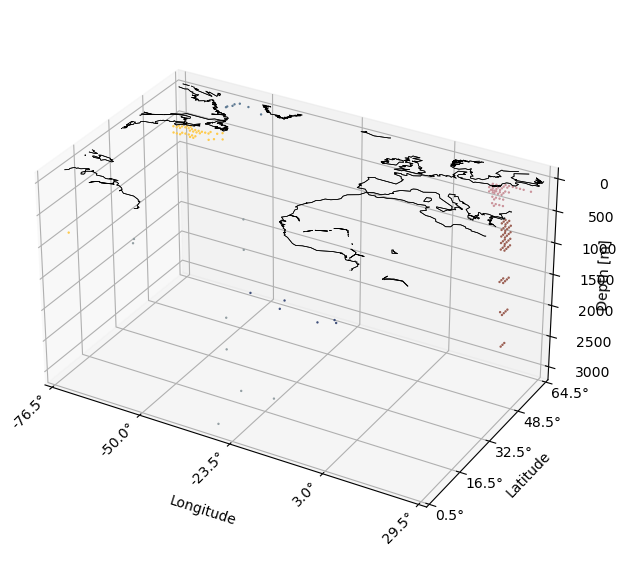

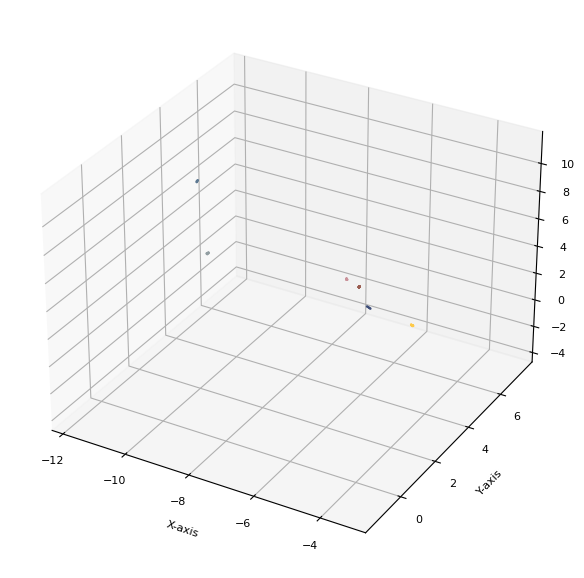

In [46]:
# Plot most certain clusters
coupled_label_plot(df[df.label.isin(uncertainty_eq0.label)])

### Most uncertain clusters

In [58]:
# Analyse most uncertain clusters
uncertainty_meq50.sort_values("uncertainty", ascending=False)

,label,uncertainty
319,299,95.000000
318,211,91.145833
317,379,90.500000
316,130,89.041667
315,133,89.000000
...,...,...
240,323,51.600000
239,292,50.500000
238,167,50.214286
237,164,50.000000


In [87]:
# Check depth and longitude ranges for each cluster
for l in uncertainty_meq50.label.unique():
    filtered = df[df.label == l]
    print(l, filtered.LEV_M.unique(), filtered.LONGITUDE.min(), filtered.LONGITUDE.max())

325 [  0.  50. 100.] -40.5 -15.500000000000004
164 [ 300.  500. 2000. 3000.] -66.5 -35.5
167 [ 500. 1000.] -64.5 5.500000000000004
292 [ 400. 1000.] -59.49999999999999 -37.5
323 [ 100.  300.  500. 1000.] -34.5 9.500000000000004
105 [ 200.  300.  400.  500. 1000. 1500.] -57.49999999999999 -29.5
275 [1500. 2000.] -49.5 -22.5
146 [  0.  50. 100.] -67.5 23.5
45 [200. 300. 400. 500.] -76.5 5.500000000000004
357 [ 50. 100. 200.] -34.5 -5.500000000000004
53 [ 200.  300.  400. 1000. 1500.] -75.5 -8.500000000000004
152 [1500. 2000.] -76.5 -9.500000000000004
182 [  50.  200.  500. 1500.] -71.5 22.5
301 [0.] 21.500000000000004 29.5
216 [300. 400.] -75.5 -35.5
28 [  0.  50. 100. 200. 300.] -64.5 6.500000000000004
157 [ 50. 100.] -56.49999999999999 -17.500000000000004
345 [300. 400.] -46.5 -12.500000000000004
183 [300. 400. 500.] -31.5 7.500000000000004
69 [  0.  50. 100.] -70.5 18.500000000000004
128 [ 200. 1000. 1500.] -74.5 -5.500000000000004
328 [ 500. 1500. 2000.] -71.5 -10.500000000000004
358

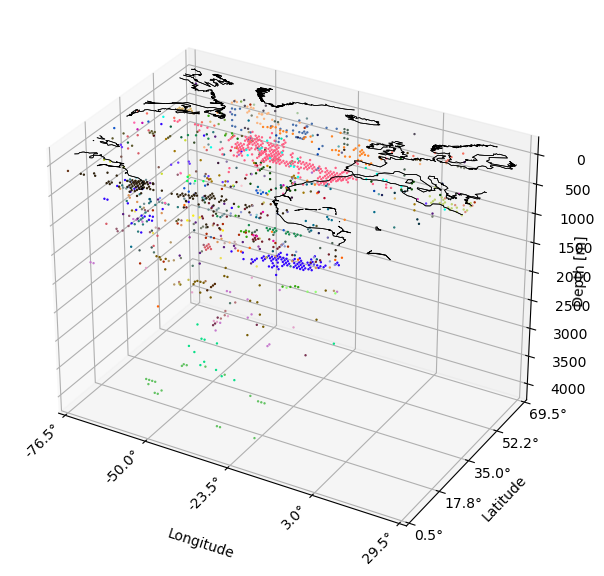

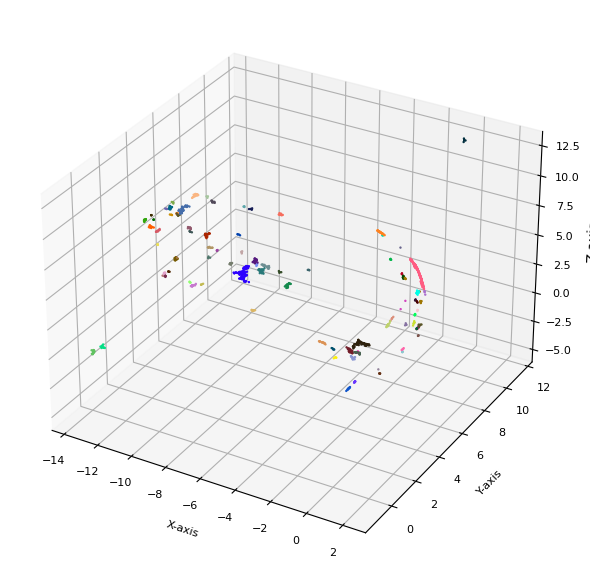

In [77]:
coupled_label_plot(df[df.label.isin(uncertainty_meq50.label.unique())], color_label="color")

### Case study: Mediterranean Sea

In [47]:
print("Uncertainty statistics (mean, std)")
round(medi_selection.uncertainty.mean(), 2), round(medi_selection.uncertainty.std(), 1)

Uncertainty statistics (mean, std)


(13.08, 20.7)

C:\Users\yvjennig\AppData\Local\Temp\ipykernel_12464\3821806950.py:49: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


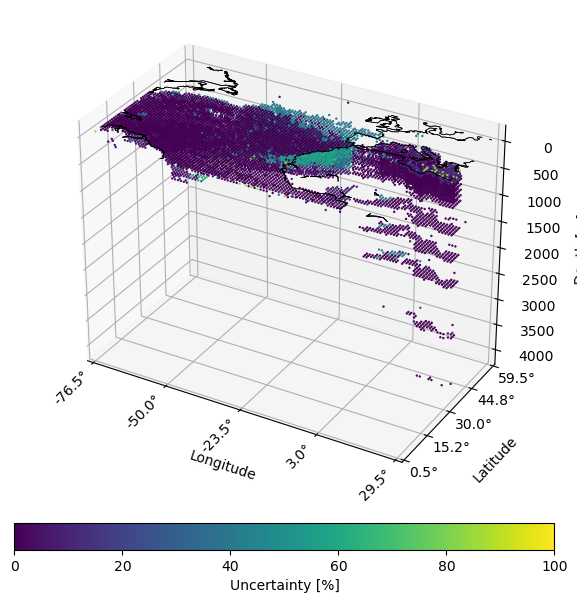

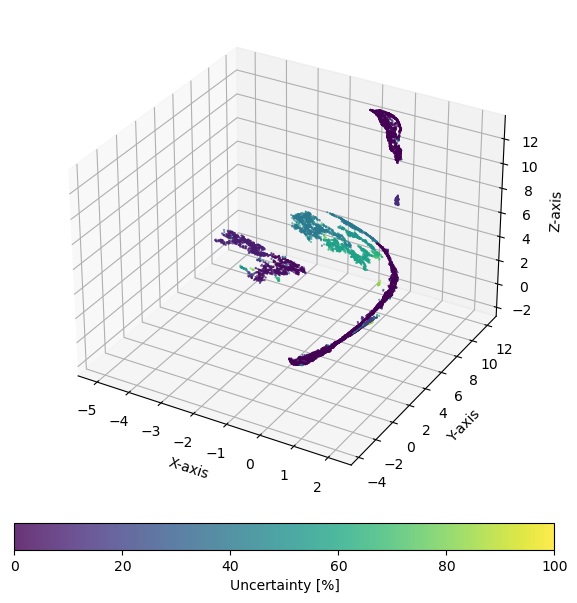

In [28]:
coupled_label_plot_uncertainties(medi_selection, save_dir=config.output_dir_plots_high_res, suffix="_medi_uncertainty", figsize=(6, 6), dpi=1000, 
                                 xlabelpad=10, ylabelpad=5, zlabelpad=15, 
                                 adjust_left=-0.05, adjust_right=1, adjust_top=1, adjust_bottom=0.1)

C:\Users\yvjennig\AppData\Local\Temp\ipykernel_12464\3821806950.py:49: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


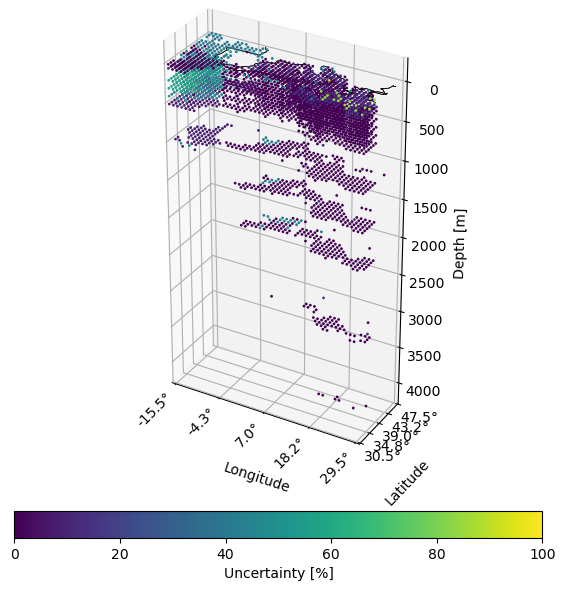

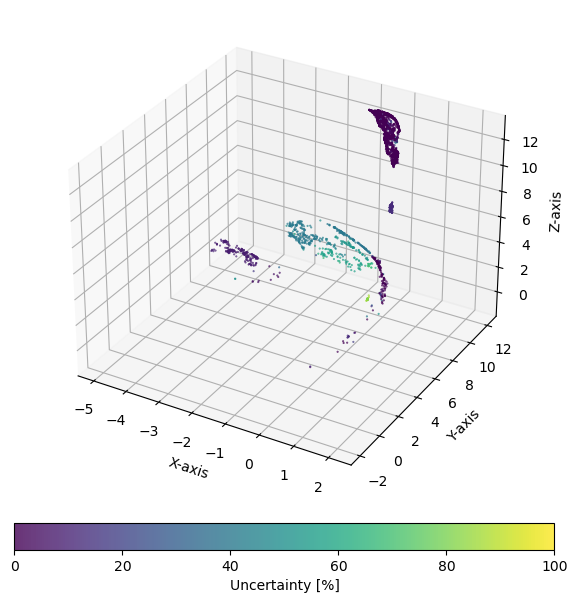

In [29]:
coupled_label_plot_uncertainties(medi_geo, save_dir=config.output_dir_plots_high_res, suffix="_medi_uncertainty_geo", figsize=(6, 6), dpi=1000, 
                                 xlabelpad=10, ylabelpad=5, zlabelpad=20, pointsize=1,
                                adjust_left=-0.05, adjust_right=1, adjust_top=0.98, adjust_bottom=0.1,
                                cpad=0.1)

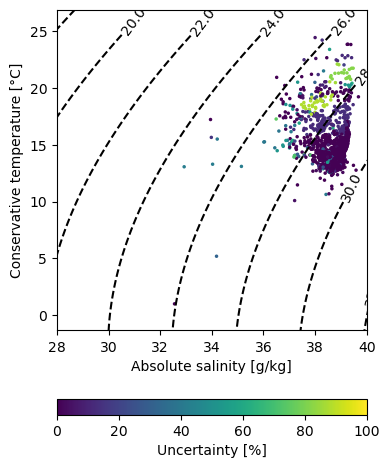

In [37]:
plot_ts_uncertainty(medi, figsize=(4, 5), dpi=1000, ncols=None, xlim=[28, 40], save_as=f"{config.output_dir_plots_high_res}medi_uncertainty_ts.png")

### Case study: Deep Atlantic waters

In [71]:
print("Uncertainty statistics (mean, std)")
round(deep_selection.uncertainty.mean(), 2), round(deep_selection.uncertainty.std(), 1)

Uncertainty statistics (mean, std)


(7.74, 13.4)

C:\Users\yvjennig\AppData\Local\Temp\ipykernel_12464\3821806950.py:49: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


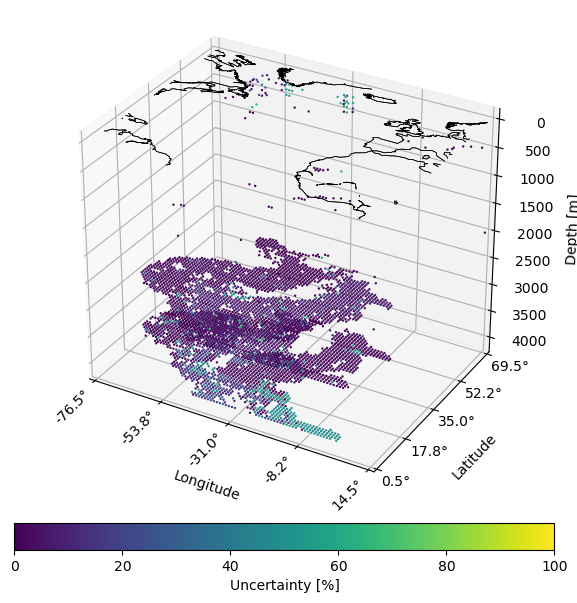

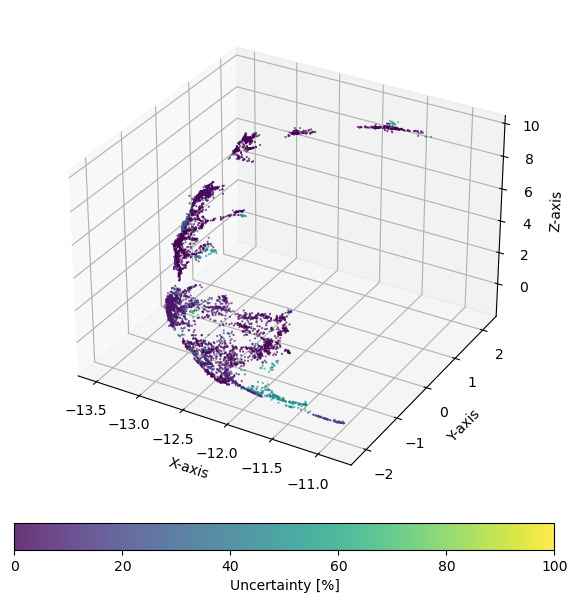

In [65]:
coupled_label_plot_uncertainties(deep_selection, save_dir=config.output_dir_plots_high_res, suffix="_deep_uncertainty", figsize=(6, 6), dpi=1000, 
                                 xlabelpad=10, ylabelpad=5, zlabelpad=15, 
                                 adjust_left=-0.05, adjust_right=1, adjust_top=1, adjust_bottom=0.1)

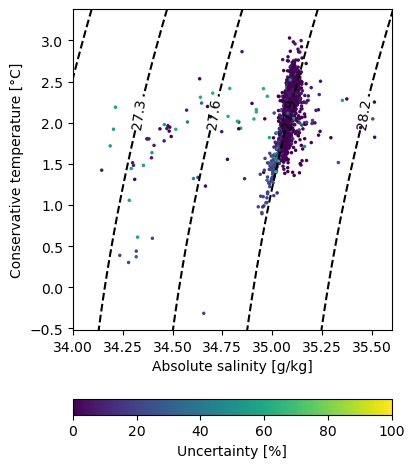

In [66]:
plot_ts_uncertainty(deep_selection, figsize=(4, 5), dpi=1000, ncols=None, xlim=[34, 35.6], save_as=f"{config.output_dir_plots_high_res}/deep_uncertainty_ts.png")

### Case study: Labrador Sea

In [90]:
print("Uncertainty statistics (mean, std)")
print(round(lab_selection.uncertainty.mean(), 2), round(lab_selection.uncertainty.std(), 1), round(lab_selection.uncertainty.median(), 2))

Uncertainty statistics (mean, std)
10.73 15.4 4.0


C:\Users\yvjennig\AppData\Local\Temp\ipykernel_12464\3821806950.py:49: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


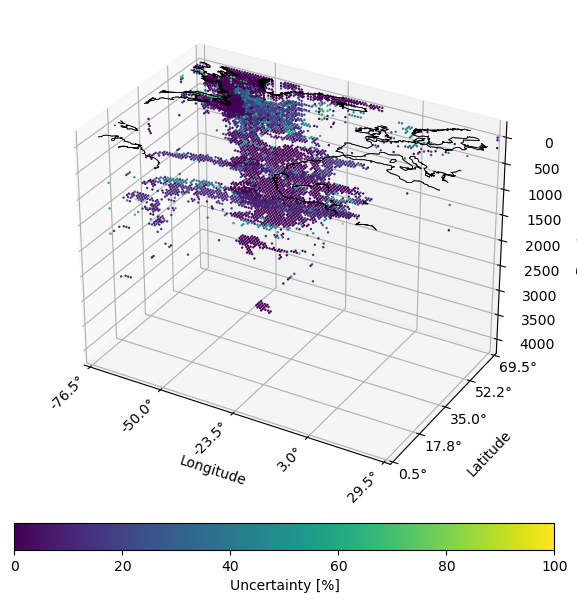

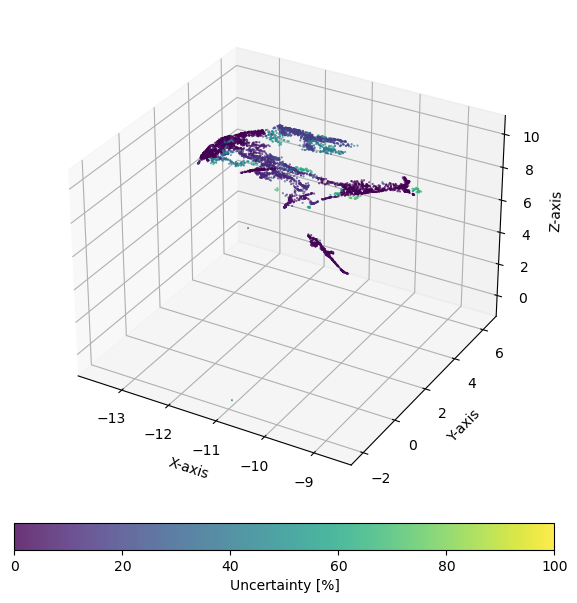

In [88]:
coupled_label_plot_uncertainties(lab_selection, save_dir=config.output_dir_plots_high_res, suffix="_lab_uncertainty", figsize=(6, 6), dpi=1000, 
                                 xlabelpad=10, ylabelpad=5, zlabelpad=15, 
                                 adjust_left=-0.05, adjust_right=1, adjust_top=1, adjust_bottom=0.1)

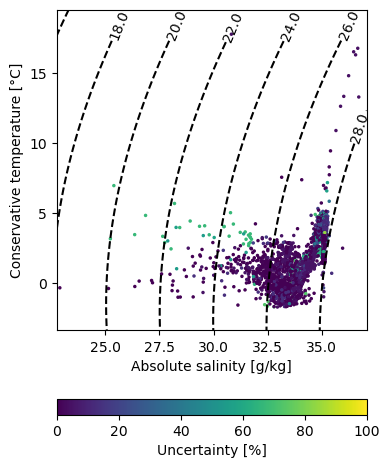

In [89]:
plot_ts_uncertainty(lab_selection, figsize=(4, 5), dpi=1000, ncols=None, xlim=None, save_as=f"{config.output_dir_plots_high_res}lab_uncertainty_ts.png")

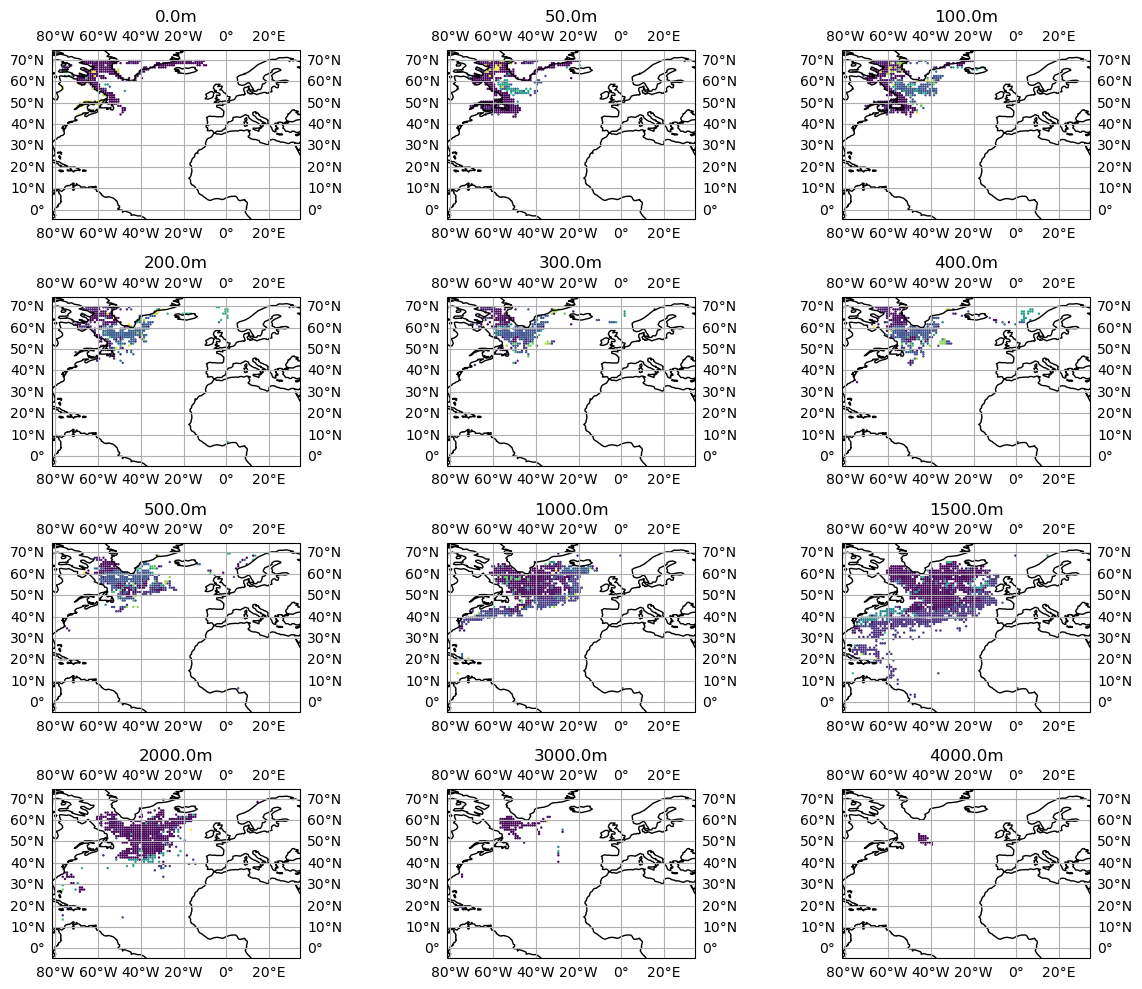

In [96]:
plot_each_depth_level(lab_selection, color_label="uncertainty")